# Explo data 22_Update
- Train -> 2025/07/20 (> )
- Test -> 2026/01/22 (> 6 months)


## Import & definitions

In [6]:
import os
# import hashlib
# import sys
# from pathlib import Path
# import re
# import random
# import time
# import math
# import itertools
# from datetime import timedelta
# from datetime import timezone
# from datetime import datetime
# import json
# import joblib
# Third Party
import pickle
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# from sklearn.metrics import make_scorer
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import train_test_split 
# from sklearn.preprocessing import StandardScaler
# from sklearn.experimental import enable_halving_search_cv  # noqa: F401
# from sklearn.model_selection import HalvingRandomSearchCV
# from sklearn.model_selection import TimeSeriesSplit
# from scipy.stats import randint
# from scipy.stats import uniform
# import scipy.stats as stats
# from scipy.stats.mstats import mquantiles
import xgboost as xgb
# from helpers.ocean_helpers import save_list
# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers
# from tensorflow.keras.callbacks import EarlyStopping
# from keras.regularizers import L1L2

# PLOT
import matplotlib.pyplot as plt
# import matplotlib as mpl
import seaborn as sns
sns.set_theme()
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
# definitions
DT_PAST = 5 # 5 min
PAST_HISTORY = int(6*60 / DT_PAST) #  6 hours in 5mins units : used to predict next values in future
FUTURE_TARGET = 12 + 3 # number of 5 min to predict  : 15 : 1h15
STEP = 1
BATCH_SIZE = 256 #128 #32
TRAIN_SPLIT_RATIO = 0.9 #0.8 #0.9891 # 1-(60/5*24)/50977
TARGET_NAME = "Close_ETH"
MODE_TRAIN_AE = True
target_level = 0.0045
R = 2 

# LIST_SEEDS = [1] #LIST_SEEDS = [1,2,3,4,5]
# MODE_AUTO_SELECT = 0 #1 #   #0 # 0: False, 1: True, 2: from disk
# MODE_TRAIN_PREDICTOR = True # False
# EPOCHS_AE = 1#30
# PATIENCE_AE = 0#10
# LIST_UNITS_ENC_AE = [64]
# LIST_UNITS_AE = [16]
# LIST_DROPOUT_AE = [0.2]
# EPOCHS_PRED = 100#30
# PATIENCE_PRED = 0#10
# LIST_UNITS_PRED = [128]
# LIST_DROPOUT_PRED = [0.2]
# MODE_TRAIN_LSTM = False

mode_redo = False

# paths
path_data = "data/update"
path_data_old = "data"
#path_save_df_feat = os.path.join(path_data, "df_features_05m.csv")

#path_save_pred_vals = os.path.join(path_data, "pred_vals.csv")
#path_save_auto_select = os.path.join(path_data, "list_auto_select.csv")

#path_scaler = os.path.join(path_data, "scaler.bin")
#path_scaler_y = os.path.join(path_data, "scaler_y.bin")
# path_scaler_enc = os.path.join(path_data, "scaler_enc.bin")
# path_save_df_feat_std = os.path.join(path_data, "df_features_05m_std.csv")
# path_X_train = os.path.join(path_data, 'X_train.dat')
# path_X_train_sca = os.path.join(path_data, 'X_train_sca.dat')
# path_df_prob_comb = os.path.join(path_data, 'df_prob_comb.csv')
# path_df_prob_comb_2 = os.path.join(path_data, 'df_prob_comb_2.csv')
# path_df_prob_comb_1b = os.path.join(path_data, 'df_prob_comb_1b.csv')
# path_arr_corr_matrix_targets = os.path.join(
#     path_data, 'arr_corr_matrix_targets.npy'
# )
# path_pca = os.path.join(path_data,"pca_model.pkl")
# path_hash_pca = os.path.join(path_data, 'pca_hash.txt')


# path_mdl_autoencoder =  os.path.join(path_data, "mdl_autoencoder")
# path_mdl_encoder  =  os.path.join(path_data, "mdl_encoder")
# path_mdl_predict_lstm  =  os.path.join(path_data, "mdl_predict_lstm")
# path_mdl_predict_autoenc_lstm  =  os.path.join(
#     path_data, "mdl_predict_autoenc_lstm")


## Load old for Train, new for Test

In [7]:
# LOAD
#df_prob_comb_high_event = pd.read_pickle(os.path.join(path_data, 'df_prob_comb_high_event.pkl'))
#global_event_by_day = pd.read_pickle(os.path.join(path_data, 'global_event_by_day.pkl'))
df_combined_condition = pd.read_pickle(os.path.join(path_data_old, 'df_combined_condition.pkl'))
#df_prob_comb_high_event_test = pd.read_pickle(os.path.join(path_data, 'df_prob_comb_high_event_test.pkl'))
#global_event_by_day_test = pd.read_pickle(os.path.join(path_data, 'global_event_by_day_test.pkl'))
df_combined_condition_test = pd.read_pickle(os.path.join(path_data, 'df_combined_condition_test.pkl'))

df_targets = pd.read_pickle(os.path.join(path_data_old, "df_targets.pkl"))
df_targets_test = pd.read_pickle(os.path.join(path_data, "df_targets_test.pkl"))

with open(os.path.join(path_data_old, "list_df.pkl"), "rb") as f:
    list_df = pickle.load(f)

with open(os.path.join(path_data, "list_df_test.pkl"), "rb") as f:
    list_df_test = pickle.load(f)


In [8]:
df_targets

,target_0,target_1,target_2,target_3,target_4,target_5,target_6,target_7,target_8,target_9,target_10,target_11,target_12,target_13,target_14
0,1.000460,1.000385,0.999623,1.000293,0.999816,1.000050,0.999498,0.999506,0.999858,0.999925,0.999858,1.000226,0.999891,1.000151,0.999858
1,0.999925,0.999163,0.999833,0.999356,0.999590,0.999038,0.999046,0.999398,0.999464,0.999398,0.999766,0.999431,0.999690,0.999398,0.998803
2,0.999238,0.999908,0.999431,0.999665,0.999113,0.999121,0.999473,0.999540,0.999473,0.999841,0.999506,0.999766,0.999473,0.998879,0.998594
3,1.000670,1.000193,1.000427,0.999874,0.999883,1.000234,1.000301,1.000234,1.000603,1.000268,1.000528,1.000234,0.999640,0.999355,1.000427
4,0.999523,0.999757,0.999205,0.999213,0.999565,0.999632,0.999565,0.999933,0.999598,0.999858,0.999565,0.998971,0.998686,0.999757,0.999732
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268183,1.000254,0.999806,0.999454,1.000205,0.999273,0.999352,0.999519,0.998739,0.999816,1.002120,1.004668,1.005046,1.006342,1.005735,1.007647
268184,0.999552,0.999201,0.999951,0.999020,0.999098,0.999265,0.998485,0.999563,1.001866,1.004413,1.004791,1.006087,1.005479,1.007391,1.015585
268185,0.999649,1.000400,0.999468,0.999546,0.999714,0.998933,1.000011,1.002315,1.004863,1.005241,1.006538,1.005930,1.007843,1.016040,1.013255
268186,1.000751,0.999819,0.999897,1.000065,0.999284,1.000362,1.002668,1.005216,1.005595,1.006892,1.006284,1.008197,1.016397,1.013611,1.015324


In [9]:
# X train : df_combined_condition train
# X test: df_combined_condition_test

# Y train : high trade or not
y_comb = (list_df[0]["target_cat"] == "high")
# Y test 
y_comb_test = list_df_test[0]["target_cat"] == "high"

In [10]:
np.all(list_df_test[0]["target_cat"].values == df_targets_test["target_cat"].values)

np.True_

## Functions

In [11]:
# --- Define the new, simplified custom metric ---

def fun_nb_trade_fixed_window(y_true, y_pred):
    """
    Custom XGBoost metric to count 30-minute windows with at least one trade signal.
    Assumes each prediction corresponds to a 5-minute interval.
    
    Args:
        y_pred (np.ndarray): The array of predictions (0s and 1s).
        y_true (DMatrix): The DMatrix object with the true labels. We don't use it
                          for this specific metric, but it's part of the function signature.
    """
    window_size = 6  # 30 minutes / 5 minutes per data point

    # Calculate the number of full, non-overlapping windows we can form
    num_windows = len(y_pred) // window_size
    
    # If there are no full windows, the trade count is 0
    if num_windows == 0:
        return 0.0
    
    if y_pred.sum() == 0:
        return 0.0
    # Truncate y_pred to the largest size that is a multiple of window_size
    trunc_len = num_windows * window_size
    y_pred_truncated = y_pred[:trunc_len]

    # Reshape the predictions into a 2D array where each row is a 30-min window
    # The '-1' tells numpy to automatically calculate the number of rows
    pred_windows = y_pred_truncated.reshape(-1, window_size)

    # Sum the predictions in each window (each row)
    sum_in_windows = pred_windows.sum(axis=1)

    # Count how many windows have a sum of 1 or more (at least one trade signal)
    # The result of the boolean comparison is an array of True/False,
    # and .sum() counts the number of True values.
    total_trades = (sum_in_windows >= 1).sum()
    #precision_score(y_true, y_pred)
    # XGBoost custom metrics must return a list of (name, value) tuples
    return precision_score(y_true, y_pred) + 10*float(total_trades)


In [12]:
def fun_trade(total_trades, winrate, risk=250, R=1.23 ):
    return total_trades * risk * (winrate * (1 + R) - 1)

def fun_arr_trade(arr_trade, arr_winrate, risk=250, R=1.23):
    return arr_trade * risk * (arr_winrate * (1 + R) - 1)

def fun_trades_gain(y_true, y_pred):
    """
    Custom XGBoost metric to count 30-minute windows with at least one trade signal.
    Assumes each prediction corresponds to a 5-minute interval.
    
    Args:
        y_pred (np.ndarray): The array of predictions (0s and 1s).
        y_true (DMatrix): The DMatrix object with the true labels. We don't use it
                          for this specific metric, but it's part of the function signature.
    """
    risk = 250
    R = 1.23
    window_size = 6  # 30 minutes / 5 minutes per data point

    # Calculate the number of full, non-overlapping windows we can form
    num_windows = len(y_pred) // window_size
    
    # If there are no full windows, the trade count is 0
    if num_windows == 0:
        return 0.0
    if y_pred.sum() == 0:
        return 0.0
    
    # Truncate y_pred to the largest size that is a multiple of window_size
    trunc_len = num_windows * window_size
    y_pred_truncated = y_pred[:trunc_len]

    # Reshape the predictions into a 2D array where each row is a 30-min window
    # The '-1' tells numpy to automatically calculate the number of rows
    pred_windows = y_pred_truncated.reshape(-1, window_size)

    # Sum the predictions in each window (each row)
    sum_in_windows = pred_windows.sum(axis=1)

    # Count how many windows have a sum of 1 or more (at least one trade signal)
    # The result of the boolean comparison is an array of True/False,
    # and .sum() counts the number of True values.
    total_trades = (sum_in_windows >= 1).sum()
    #precision_score(y_true, y_pred)
    winrate = precision_score(y_true, y_pred)
    #total_gain = total_trades * risk * (winrate * (1 + R) - 1)
    total_gain = fun_trade(total_trades, winrate, risk, R )
    # XGBoost custom metrics must return a list of (name, value) tuples
    return total_gain #precision_score(y_true, y_pred) + 10*float(total_trades)


In [13]:
def fun_plot_trades_gain(arr_eval, arr_eval_train, title_str="XBGBoost model performance : total gain"):
    fig = make_subplots(
        rows=2, 
        cols=1, 
        shared_xaxes=True, 
        vertical_spacing=0.03
    )

    fig.add_trace(
        go.Scatter(y=arr_eval["fun_trades_gain"], name="total_gain test"),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Scatter(y=arr_eval_train["fun_trades_gain"], name="total_gain train"),
        row=1,
        col=1,
    )
    fig.update_layout(
        height=600,
        template="plotly_white",
        title=title_str,
        hovermode='x unified'
    )
    fig.update_xaxes(
        showspikes=True, 
        spikemode='across', 
        spikesnap='cursor',
        spikethickness=1,
        spikedash='dot'
    )

    # Optional: Add y-axis spikes for more context
    fig.update_yaxes(showspikes=True, spikedash='dot')

    fig.show()

In [14]:
def fun_decoded_nb_trade_fixed_window(arr_in):
    # arr_in = np.array(precision_score(y_true, y_pred) + 10*float(total_trades))
    return np.int64(arr_in/10), arr_in%10

def fun_winrate(nb_trade, gain=333, risk=250, R=1.23):
    return (gain / (nb_trade * risk)+1) /(1 + R)

def fun_arr_winrate(arr_nb_trade, gain=333, risk=250, R=1.23):
    return (gain / (arr_nb_trade * risk)+1) /(1 + R)


In [15]:
def plot_trading_performance(df_trades, df_feat_tot, monthly_target=333):
    """
    Generates an interactive Plotly chart analyzing trading performance.

    Args:
        df_trades (pd.DataFrame): DataFrame with columns 'capital' and 'Train' (bool).
                                  Index must be DatetimeIndex.
        df_feat_tot (pd.DataFrame): DataFrame with column 'Close_ETH_raw'.
                                    Index must be DatetimeIndex.
        monthly_target (float): Target monthly gain in $ for the benchmark curve.
                                Default is 333.

    Returns:
        plotly.graph_objects.Figure: The generated figure.
    """
    
    # --- 1. Calculate Global Statistics for Title ---
    
    # Split the data
    df_train = df_trades[df_trades["Train"]]
    df_test = df_trades[~df_trades["Train"]]

    # Constants
    SECONDS_PER_MONTH = 30.44 * 24 * 60 * 60

    def calculate_mean_monthly_gain(df):
        if df.empty: return 0
        total_pnl = df["capital"].iloc[-1] - df["capital"].iloc[0]
        duration = (df.index[-1] - df.index[0]).total_seconds()
        if duration > 0:
            # PnL / (Duration in Months)
            return total_pnl / (duration / SECONDS_PER_MONTH)
        return 0

    mean_train_gain = calculate_mean_monthly_gain(df_train)
    mean_test_gain = calculate_mean_monthly_gain(df_test)

    plot_title = (
        f"<span style='font-size: 14px;'>Global Mean Monthly Gain: "
        f"<b>Train ${mean_train_gain:,.2f}/mo</b> | "
        f"<b>Test ${mean_test_gain:,.2f}/mo</b></span>"
    )

    # --- 2. Calculate Monthly Metrics ---

    # A. Monthly Reset Min Gain Curve
    # Groups by month, starts at actual capital, adds linear growth of monthly_target
    min_gain_pieces = []
    for period, group in df_trades.groupby(pd.Grouper(freq='MS')):
        if group.empty: continue
        start_capital = group.iloc[0]['capital']
        start_date = group.index[0]
        time_elapsed = (group.index - start_date).total_seconds()
        monthly_values = start_capital + (time_elapsed / SECONDS_PER_MONTH) * monthly_target
        min_gain_pieces.append(pd.Series(monthly_values, index=group.index))

    min_gain_series = pd.concat(min_gain_pieces) if min_gain_pieces else pd.Series(dtype=float)

    # B. Monthly Return (Absolute $)
    monthly_return_abs = df_trades.groupby(pd.Grouper(freq='MS'))['capital'].apply(
        lambda x: (x.iloc[-1] - x.iloc[0]) if len(x) > 0 else 0
    )

    # C. Monthly Max Drawdown (%)
    monthly_drawdown_pct = df_trades.groupby(pd.Grouper(freq='MS'))['capital'].apply(
        lambda x: (x / x.cummax() - 1).min() * 100 if len(x) > 0 else 0
    )

    # --- 3. Create Subplots ---
    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=True,
        vertical_spacing=0.08,
        row_heights=[0.60, 0.40],
        # Enable secondary_y for both rows to handle different scales
        specs=[[{"secondary_y": True}], [{"secondary_y": True}]],
        subplot_titles=("Capital vs. Targets", "Monthly Performance: Drawdown (%) vs Return ($)")
    )

    # --- 4. Row 1: Capital & ETH ---

    # Train Capital
    if not df_train.empty:
        fig.add_trace(go.Scatter(
            x=df_train.index,
            y=df_train["capital"],
            mode='lines+markers',
            name='Train Capital',
            line=dict(width=1),
            marker=dict(size=3)
        ), row=1, col=1)

    # Test Capital
    if not df_test.empty:
        fig.add_trace(go.Scatter(
            x=df_test.index,
            y=df_test["capital"],
            mode='lines+markers',
            name='Test Capital',
            line=dict(width=1),
            marker=dict(size=3)
        ), row=1, col=1)

    # Min Gain Benchmark
    fig.add_trace(go.Scatter(
        x=min_gain_series.index,
        y=min_gain_series,
        mode='lines',
        name=f'Min Gain (${monthly_target}/mo)',
        line=dict(color='green', width=2, dash='solid'),
        opacity=0.6
    ), row=1, col=1)

    # ETH Price (Secondary Y-Axis)
    fig.add_trace(go.Scatter(
        x=df_feat_tot.index,
        y=df_feat_tot["Close_ETH_raw"],
        mode='lines',
        name='ETH Price',
        line=dict(color='grey', width=1, dash='dot')
    ), row=1, col=1, secondary_y=True)

    # --- 5. Row 2: Drawdown (%) & Return ($) ---

    # Trace 1: Max Drawdown % (Left Axis)
    fig.add_trace(go.Bar(
        x=monthly_drawdown_pct.index,
        y=monthly_drawdown_pct.values,
        name='Max Drawdown %',
        marker_color='crimson',
        opacity=0.4,
        text=[f"{val:.1f}%" for val in monthly_drawdown_pct.values],
        textposition='inside',
        textfont=dict(size=11, color='white'),
        hovertemplate='%{x|%b %Y}<br>Drawdown: %{y:.2f}%<extra></extra>'
    ), row=2, col=1, secondary_y=False)

    # Trace 2: Monthly Return $ (Right Axis)
    # Color logic: Green for positive, Red for negative
    colors = ['#00CC96' if val >= 0 else '#EF553B' for val in monthly_return_abs.values]

    fig.add_trace(go.Bar(
        x=monthly_return_abs.index,
        y=monthly_return_abs.values,
        name='Monthly Return $',
        marker_color=colors,
        opacity=0.8,
        text=[f"{val:+.0f}$" for val in monthly_return_abs.values],
        textposition='outside',
        textangle=-90,
        textfont=dict(size=14, color='green'),
        cliponaxis=False,
        hovertemplate='%{x|%b %Y}<br>PnL: %{y:+.2f}$<extra></extra>'
    ), row=2, col=1, secondary_y=True)

    # --- 6. Update Layout ---
    fig.update_layout(
        title=plot_title,
        width=1200,
        height=700,
        template="plotly_white",
        legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
        margin=dict(b=100) # Extra bottom margin for vertical text
    )

    # Row 1 Axes Labels
    fig.update_yaxes(title_text="Capital [$]", row=1, col=1, secondary_y=False)
    fig.update_yaxes(title_text="ETH Price [$]", row=1, col=1, secondary_y=True)

    # Row 2 Axes Labels & Styling
    fig.update_yaxes(title_text="Drawdown [%]", row=2, col=1, secondary_y=False, color='crimson')
    fig.update_yaxes(title_text="Monthly Return [$]", row=2, col=1, secondary_y=True, color='black')
    
    # Add a zero line for the return chart
    fig.update_yaxes(zeroline=True, zerolinewidth=1, zerolinecolor='black', row=2, col=1)

    return fig

In [16]:
def fun_arr_winrate(arr_nb_trade, gain, risk, R):
    """Mock function to simulate win rate calculation."""
    # This is a placeholder to make the example runnable.
    # The formula is derived from a common trading gain formula.
    return (gain / arr_nb_trade + risk) / (risk * (1 + R))

# --- Updated plotting function ---

def fun_plot_pre_trade(df, gain_period_min=333, gain_period_bingo=1000):

    arr_nb_trade_winrate_train = np.linspace(max(1, min(df["trades_train"])), max(df["trades_train"]), 100)
    arr_winrate_min_train = fun_arr_winrate(arr_nb_trade_winrate_train, gain=gain_period_min, risk=250, R=1.23)
    arr_winrate_bingo_train = fun_arr_winrate(arr_nb_trade_winrate_train, gain=gain_period_bingo, risk=250, R=1.23)

    # --- Create the Plot with opacity for the test data ---
    fig = px.scatter(
        df,
        x='trades_test',
        y='precision_test',
        title="Evaluation Precision vs. Number of Trades",
        color_discrete_sequence=["#3CB620"], # Green for test data
        opacity=0.6,  # Added opacity for the main scatter plot
    )
    # Customize the hover template
    fig.update_traces(
            hovertemplate="Run Index: %{customdata[0]}<br>" +
                "Gain Train: %{customdata[1]:.2f}<br>" +
                "Trades Train: %{customdata[3]:.2f}<br>" +
                "Winrate Train: %{customdata[4]:.4f}<br>" +
                "<b>Gain Test: %{customdata[2]:.2f}</b><br>" +
                "Trades Test: %{x:.2f}<br>" +
                "Winrate Test: %{y:.4f}<br>" + # Corrected from Winrate Train
                    "<extra></extra>",
            customdata=df[['run_index', 'gain_train', "gain_test", "trades_train", "precision_train"]],
            name="test" # Assign a name for the legend
    )

    # add precision = f(nb_trade) to have a gain = 333/mth
    fig.add_scatter(
        x=arr_nb_trade_winrate_train,
        y=arr_winrate_min_train,
        mode='lines',
        line=dict(color='red', width=2),
        line_dash="dash",
        name="333$/mth Precision",
        hovertemplate=f"Gain: {gain_period_min:.2f}<br>" +
                    "Number of Trades: %{x}<br>" +
                    "Precision: %{y:.4f}<br>" +
                    "<extra></extra>",
    )
    # add precision = f(nb_trade) to have a gain = 1000/mth
    fig.add_scatter(
        x=arr_nb_trade_winrate_train,
        y=arr_winrate_bingo_train,
        mode='lines',
        line=dict(color='blue', width=2),
        line_dash="dash",
        name="1000$/mth Precision",
        hovertemplate=f"Gain: {gain_period_bingo:.2f}<br>" +
                    "Number of Trades: %{x}<br>" +
                    "Precision: %{y:.4f}<br>" +
                    "<extra></extra>",
    )
    # add train data with opacity
    fig.add_trace(
        go.Scatter(
            x=df["trades_train"],
            y=df["precision_train"],
            name="train",
            mode="markers",
            # Added marker dict to set color and opacity for the train data
            marker=dict(
                color="#FF7F0E", # Orange for train data
                opacity=0.6
            ),
            hovertemplate="Run Index: %{customdata[0]}<br>" +
                "<b>Gain Train: %{customdata[1]:.2f}</b><br>" +
                "Trades Train: %{x:.2f}<br>" +
                "Winrate Train: %{y:.4f}<br>" +
                "Gain Test: %{customdata[2]:.2f}<br>" +
                "Trades Test: %{customdata[3]:.2f}<br>" +
                "Winrate Test: %{customdata[4]:.4f}<br>" +
                    "<extra></extra>",
            customdata=df[['run_index', 'gain_train', "gain_test", "trades_test", "precision_test"]],
        )
    )

    fig.update_layout(
        xaxis_title="Number of Trades / mth",
        yaxis_title="Precision",
        font=dict(family="Arial, sans-serif", size=14),
        height=600,
        legend_title_text='Data Type' # Add a title to the legend
    )

    fig.show()



In [17]:
def fun_plot_xgb_rounds(df, gain_period_min=333, gain_period_bingo=1000):
    """
    Plots XGBoost model performance with semi-transparent markers.
    """
    layout = dict(
        hoversubplots="axis",
        title=dict(text="XBGBoost model performance"),
        hovermode="x",
        grid=dict(rows=3, columns=1),
        height=600,
        xaxis_title="XGB Rounds",
        yaxis=dict(
            title="Trades"
        ),
        yaxis2=dict(
            title="Precision"
        ),
        yaxis3=dict(
            title="Gain"
        )
    )

    # Define marker styles for train and test to reduce repetition
    # The 'opacity' property (from 0 to 1) controls the alpha effect.
    train_marker = dict(color="blue", opacity=0.5)
    test_marker = dict(color="red", opacity=0.5)

    data = [
        go.Scatter(x=df["run_index"], y=df["trades_train"], xaxis="x", yaxis="y", name="trades train", mode="markers", marker=train_marker),
        go.Scatter(x=df["run_index"], y=df["trades_test"], xaxis="x", yaxis="y", name="trades test",  mode="markers", marker=test_marker),
        go.Scatter(x=df["run_index"], y=df["precision_train"], xaxis="x", yaxis="y2", name="pre train",  mode="markers", marker=train_marker),
        go.Scatter(x=df["run_index"], y=df["precision_test"], xaxis="x", yaxis="y2", name="pre test",  mode="markers", marker=test_marker),
        go.Scatter(x=df["run_index"], y=df["gain_train"], xaxis="x", yaxis="y3", name="gain train",  mode="markers", marker=train_marker),
        go.Scatter(x=df["run_index"], y=df["gain_test"], xaxis="x", yaxis="y3", name="gain test",  mode="markers", marker=test_marker),
    ]

    fig = go.Figure(data=data, layout=layout)

    fig.add_hline(
        y=gain_period_min,
        xref="x",
        yref="y3",
        line_dash="dot",
        line=dict(color='red', width=2),
        annotation_text=f"Gain: {gain_period_min:.2f}$/mth",
        annotation_position="bottom right",
        annotation_font_color="red",
        annotation_font_size=8,
        row=3,
        col=1,
    )
    fig.add_hline(
        y=gain_period_bingo,
        xref="x",
        yref="y3",
        line_dash="dot",
        annotation_text=f"Gain: {gain_period_bingo:.2f}$/mth",
        annotation_position="top right",
        annotation_font_color="blue",
        annotation_font_size=8,
        row=3,
        col=1,
    )
    fig.update_xaxes(
        showspikes=True,
        spikemode='across',
        spikesnap='cursor',
        spikethickness=1,
        spikedash='dot',
    )
    fig.show()




In [18]:
def sum_upfront_1h(arr_in):
    """
    Calculates the number of rising edges in a pandas Series for one hour limited to 1

    A rising edge is defined as a transition from 0 to 1.

    Args:
        ser_in: A pandas Series containing numerical data (presumably 0s and 1s).

    Returns:
        The total count of rising edges (0 to 1 transitions).
    """

    previous_values = arr_in.shift(1, fill_value=0)

    rising_edges = (arr_in == 1) & (previous_values == 0)

    if rising_edges.sum() >= 1:
        return 1
    else:
      return 0


# Eval number of trades on train 

In [19]:
sum_upfront_1h(y_comb)

1

In [20]:
y_comb

date_ETH
2023-01-01 00:00:00    False
2023-01-01 00:05:00    False
2023-01-01 00:10:00    False
2023-01-01 00:15:00    False
2023-01-01 00:20:00    False
                       ...  
2025-07-20 04:30:00     True
2025-07-20 04:35:00     True
2025-07-20 04:40:00     True
2025-07-20 04:45:00     True
2025-07-20 04:50:00     True
Name: target_cat, Length: 268188, dtype: bool

In [23]:
y_comb_1d = y_comb.resample("h").apply(sum_upfront_1h).resample("D").sum()
y_comb_1d

date_ETH
2023-01-01     4
2023-01-02     9
2023-01-03     6
2023-01-04     9
2023-01-05     5
              ..
2025-07-16    21
2025-07-17    23
2025-07-18    22
2025-07-19    22
2025-07-20     5
Freq: D, Name: target_cat, Length: 932, dtype: int64

In [29]:
y_comb_1d.shape[0]

932

In [31]:
y_comb.shape[0]

268188

In [39]:
print(f"Nb possible trades high on Train: {y_comb_1d.sum()} / {y_comb_1d.shape[0]} days")
print(f"Nb of possible trade per day ; {y_comb_1d.sum() / y_comb_1d.shape[0]:.2f}")
print(f"5-min samples leading to a high trade {y_comb_1d.sum() / y_comb.shape[0] * 100:.2f} % ")

Nb possible trades high on Train: 13902 / 932 days
Nb of possible trade per day ; 14.92
5-min samples leading to a high trade 5.18 % 


In [40]:
288*0.05

14.4

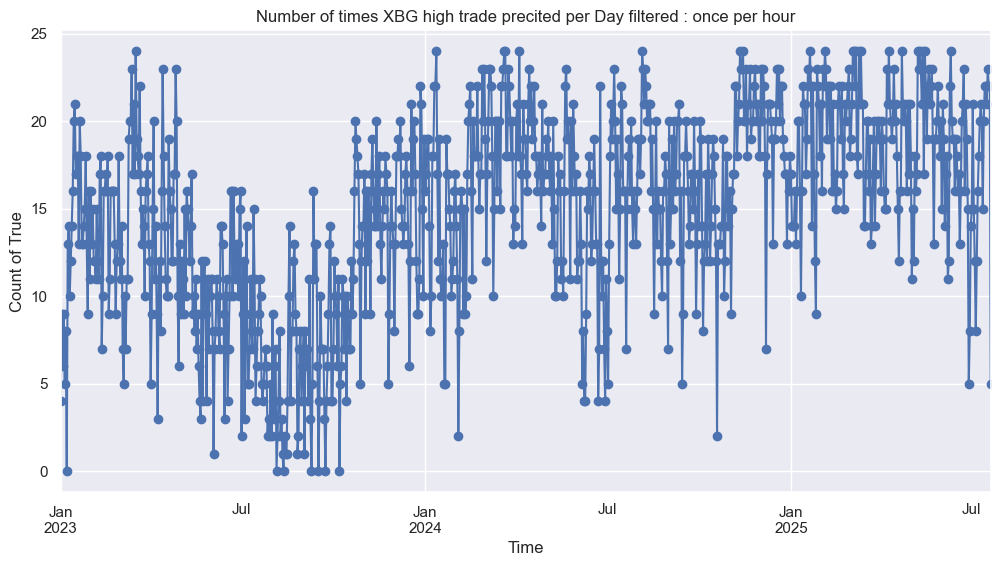

In [ ]:
y_comb_1d.plot(figsize=(12, 6), marker="o")
plt.title("Number of times XBG high trade precited per Day filtered : once per hour")
plt.xlabel("Time")
plt.ylabel("Count of True")
plt.grid(True)